In [1]:
#Import the warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn import preprocessing 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
from sklearn import svm
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks

In [5]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, \
accuracy_score, f1_score, classification_report

In [6]:
data_df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
data_df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [7]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [8]:
data_df.isna().any().sum()

np.int64(0)

In [9]:
cols = ["#00EE00","#EE0000"]

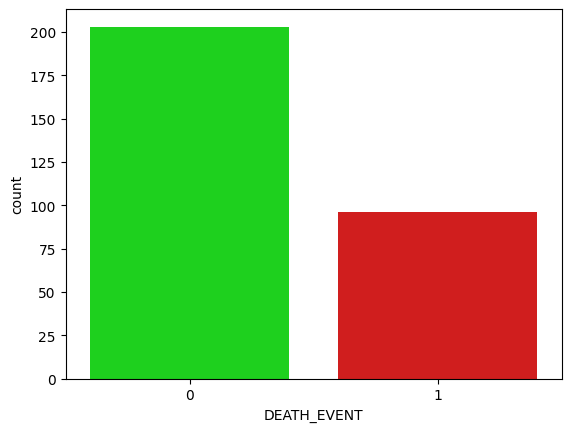

In [10]:
ax = sns.countplot(x=data_df["DEATH_EVENT"],palette=cols)

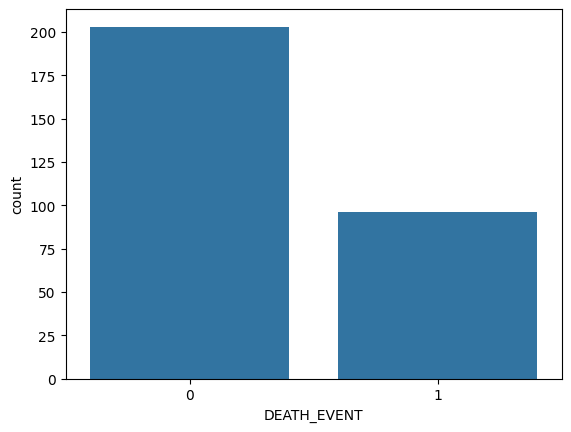

In [11]:
ax = sns.countplot(x="DEATH_EVENT",data=data_df)

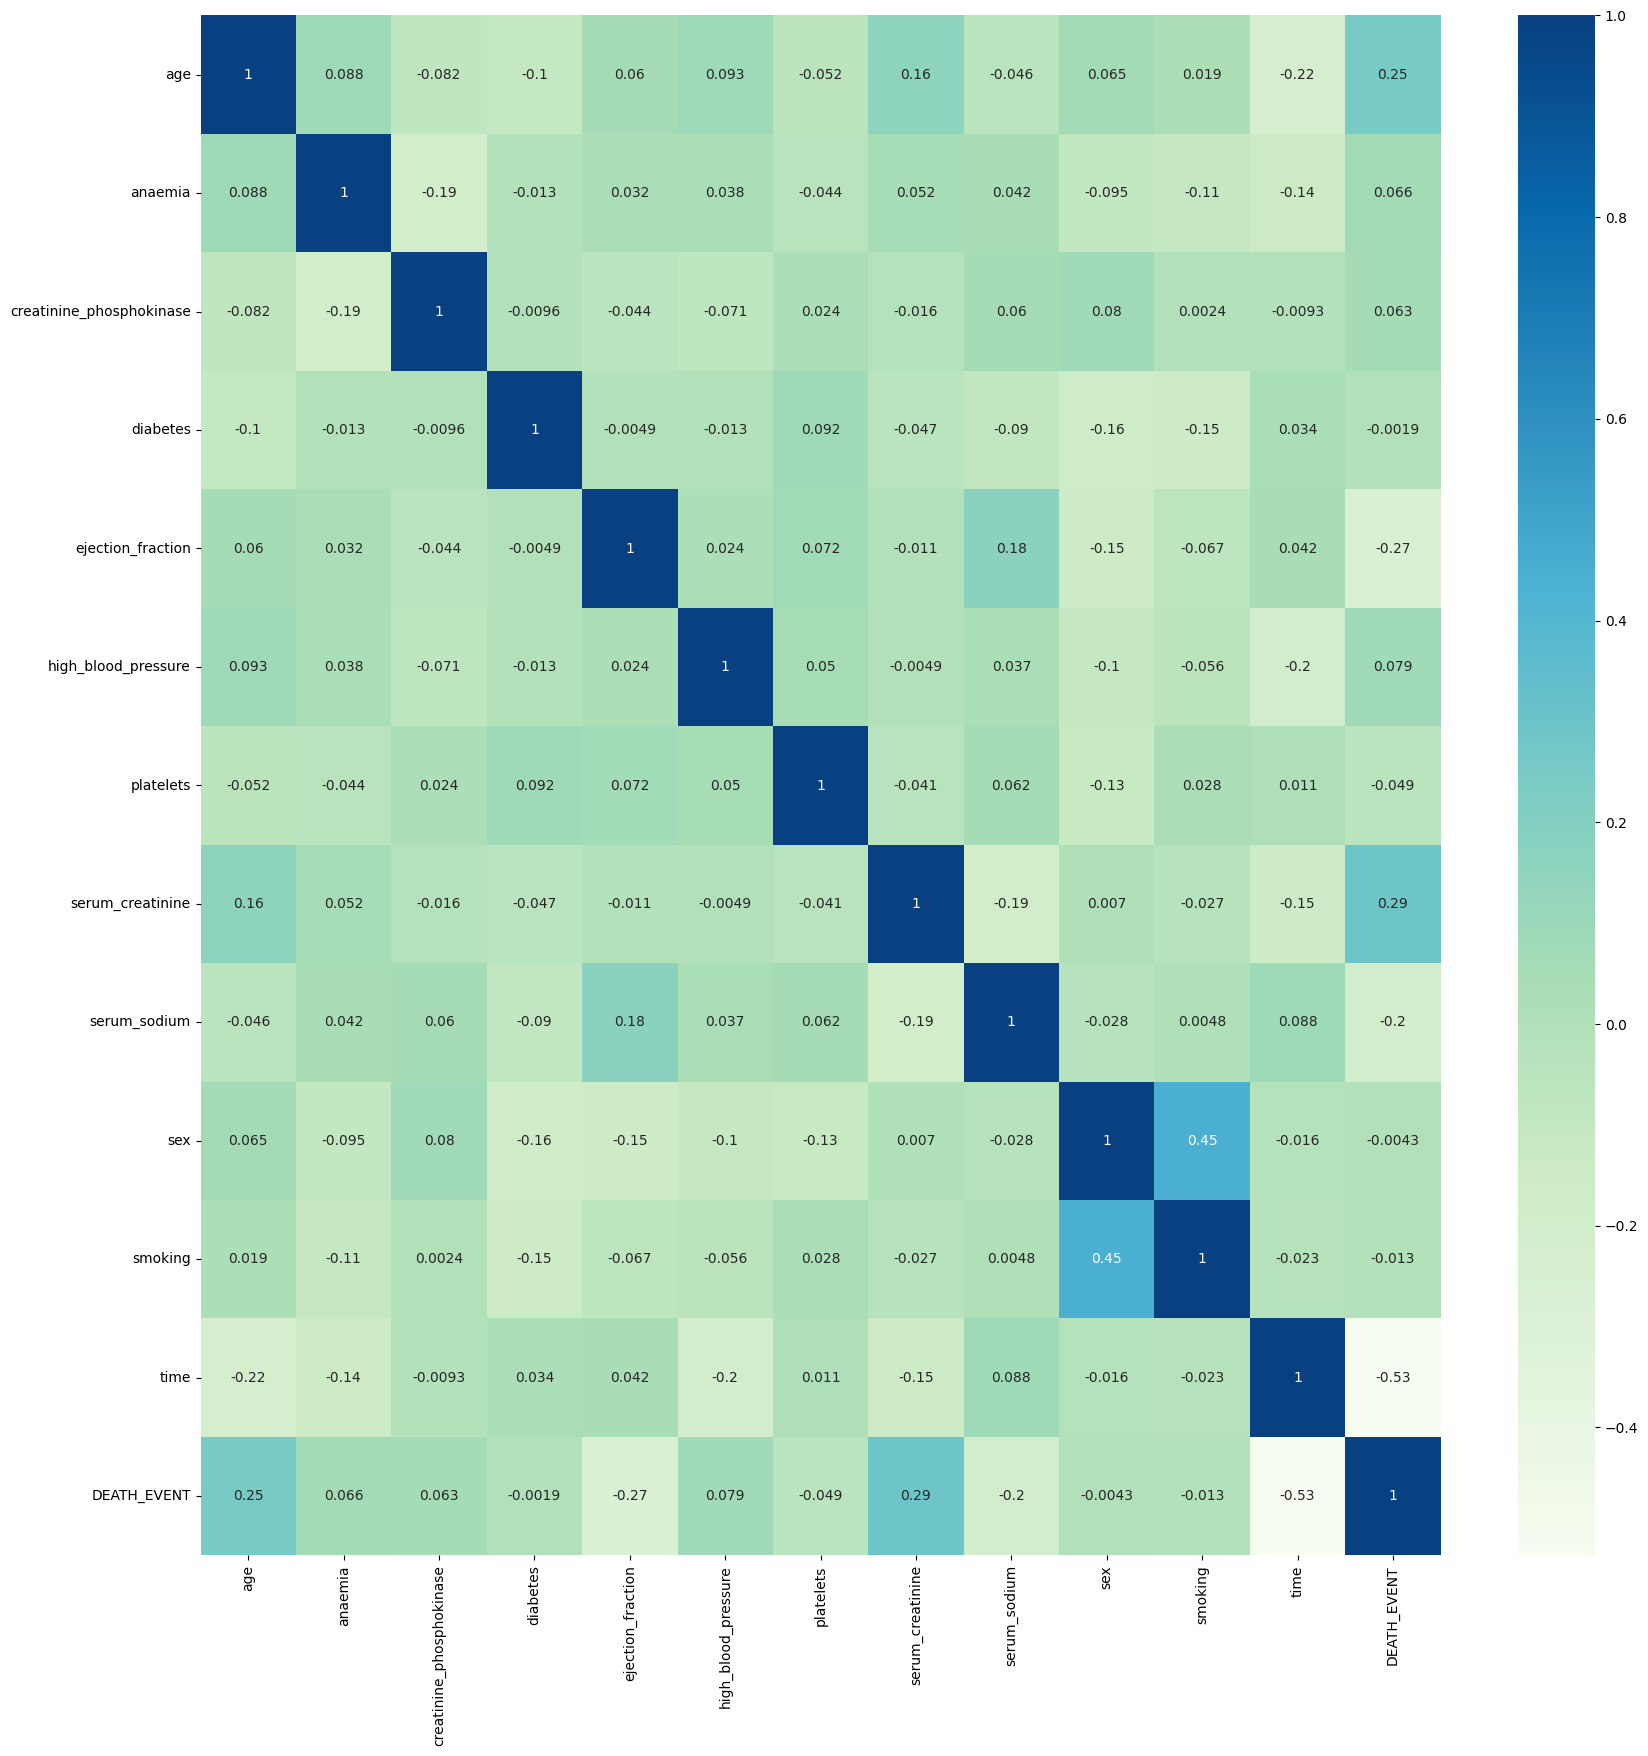

In [12]:
plt.figure(figsize=(20,20))
sns.heatmap(data_df.corr(),cmap="GnBu",annot=True)
plt.show()

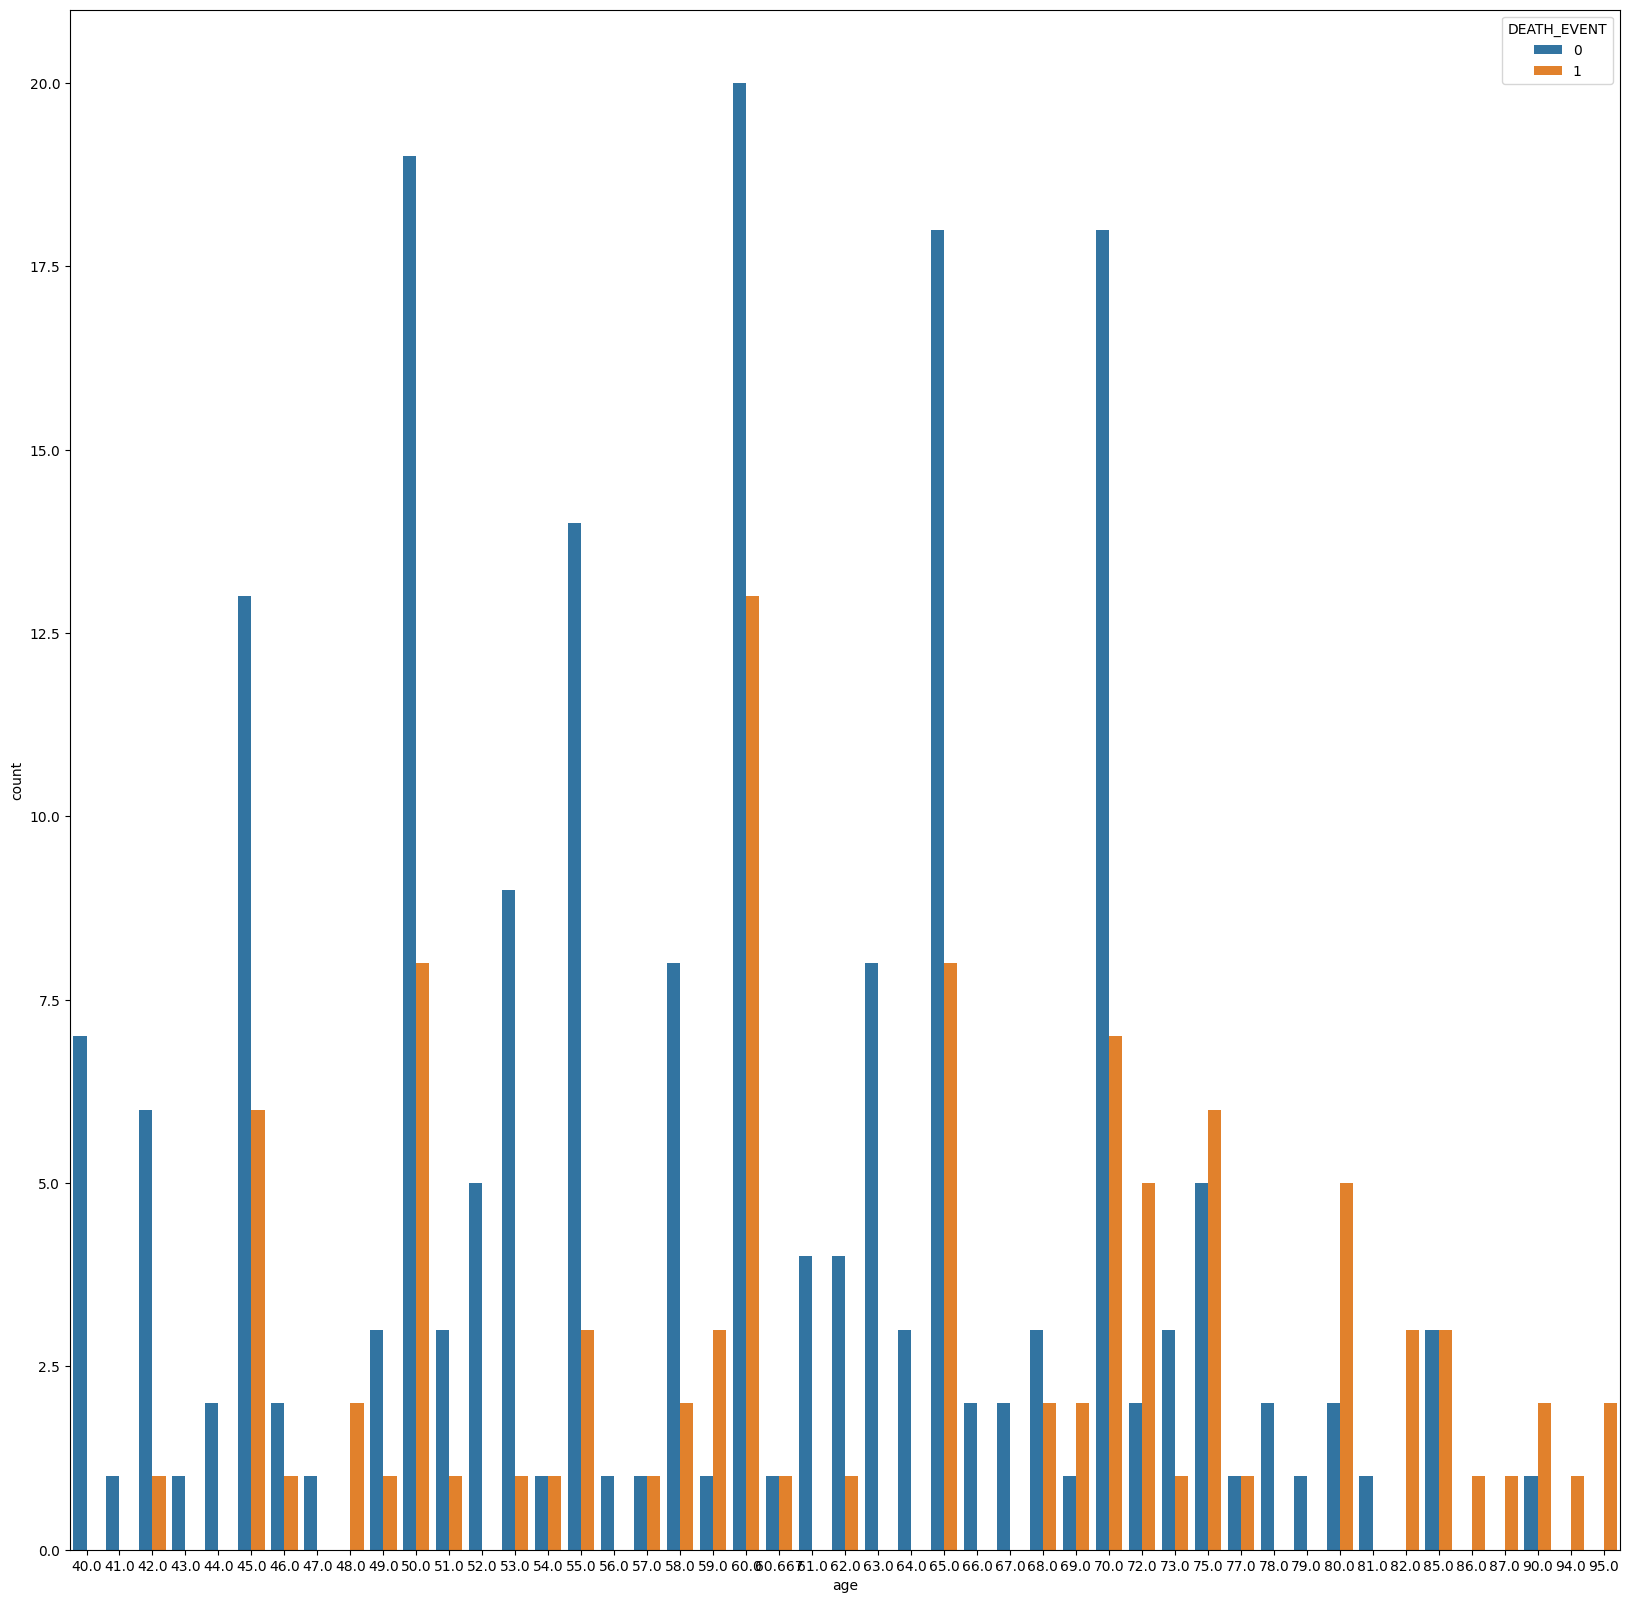

In [13]:
plt.figure(figsize=(20,20))
sns.countplot(x=data_df["age"],data=data_df,hue="DEATH_EVENT")
plt.show()

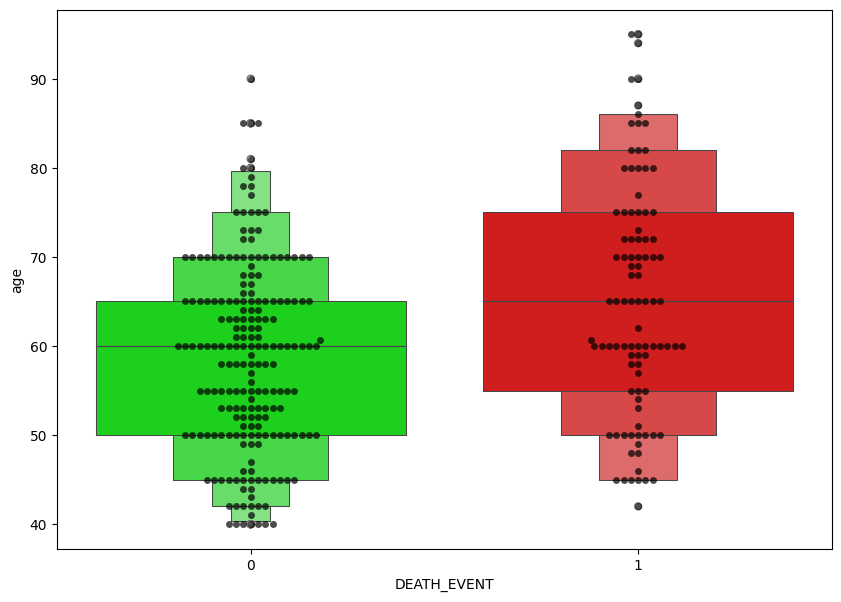

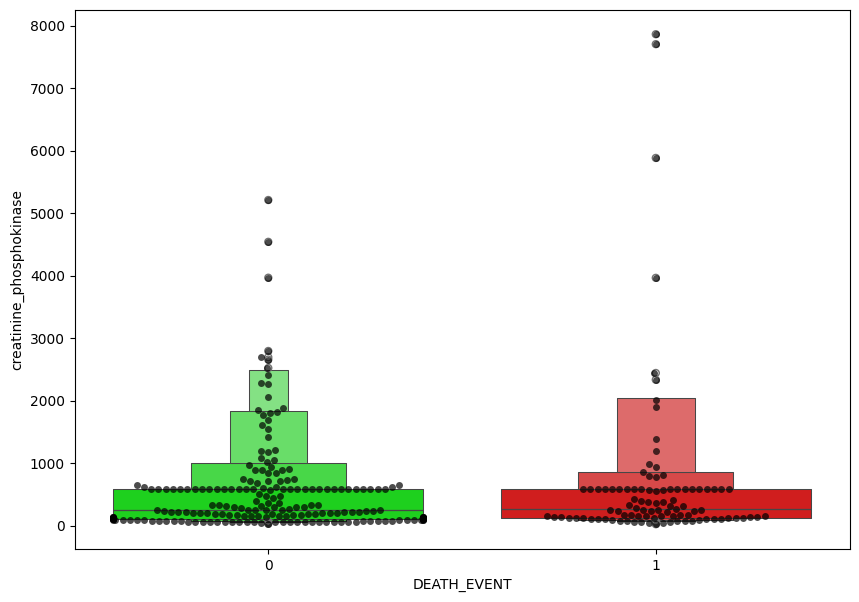

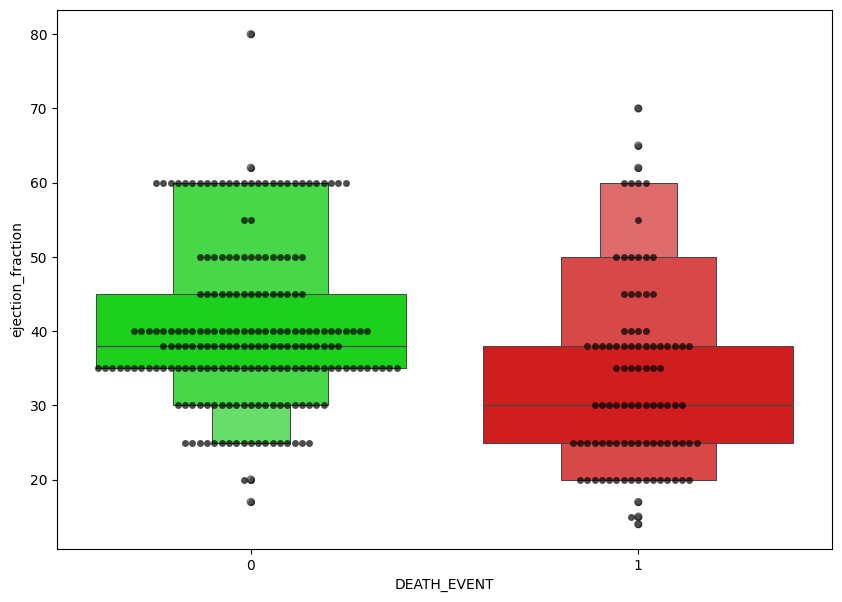

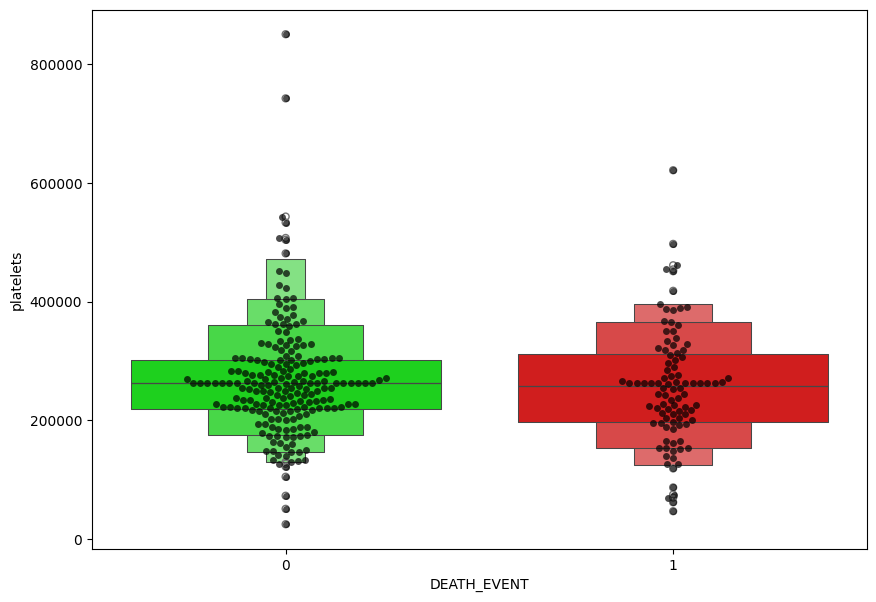

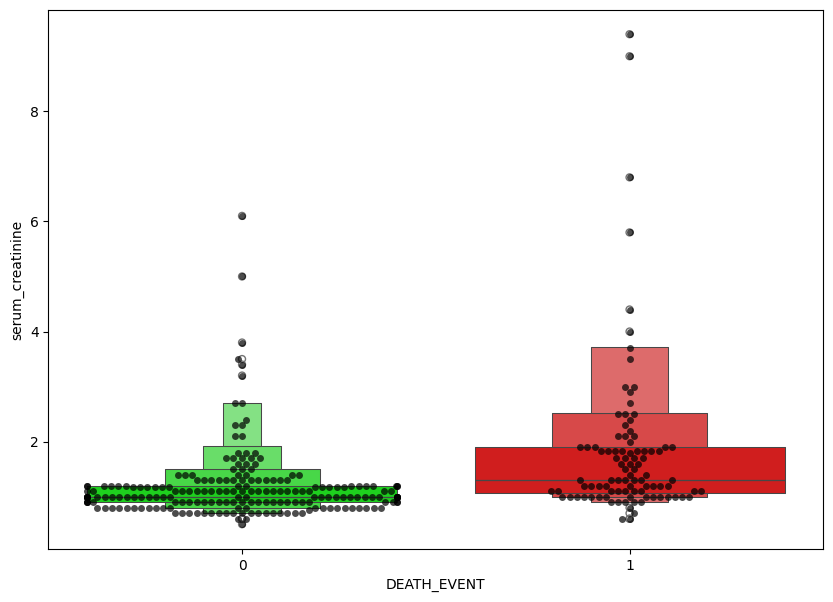

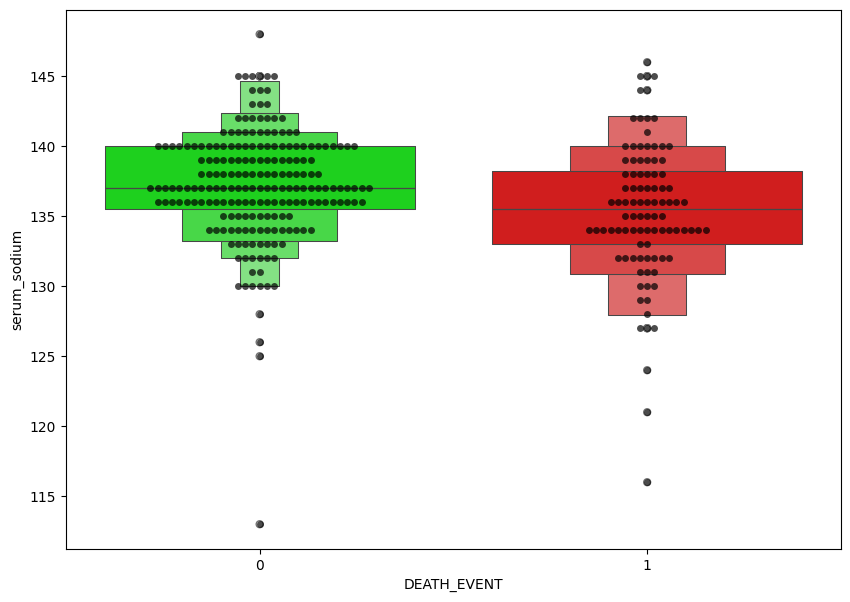

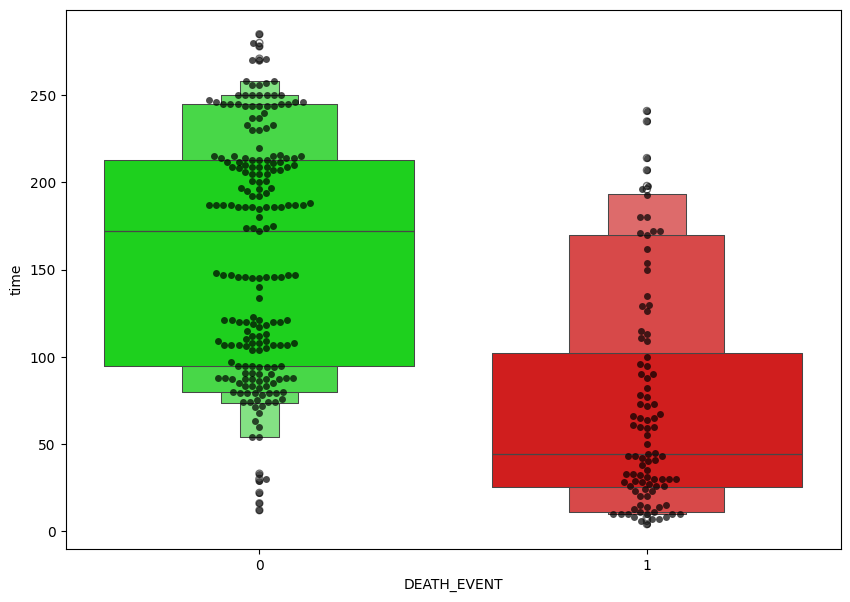

In [14]:
features = ["age","creatinine_phosphokinase","ejection_fraction","platelets","serum_creatinine",
            "serum_sodium","time"]
for i in features:
    plt.figure(figsize=(10,7))
    sns.swarmplot(x=data_df["DEATH_EVENT"],y=data_df[i],color="black",alpha=0.7)
    sns.boxenplot(x=data_df["DEATH_EVENT"],y=data_df[i],palette=cols)
    plt.show()

In [15]:
x= data_df.drop(["DEATH_EVENT"],axis=1)
y= data_df["DEATH_EVENT"]

In [16]:
col_names = list(x.columns)
ss = StandardScaler()
X_scaled = ss.fit_transform(x)
X_scaled = pd.DataFrame(X_scaled, columns=col_names)

In [17]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,5.703353e-16,1.001676,-1.754448,-0.828124,-0.070223,0.771889,2.877170
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


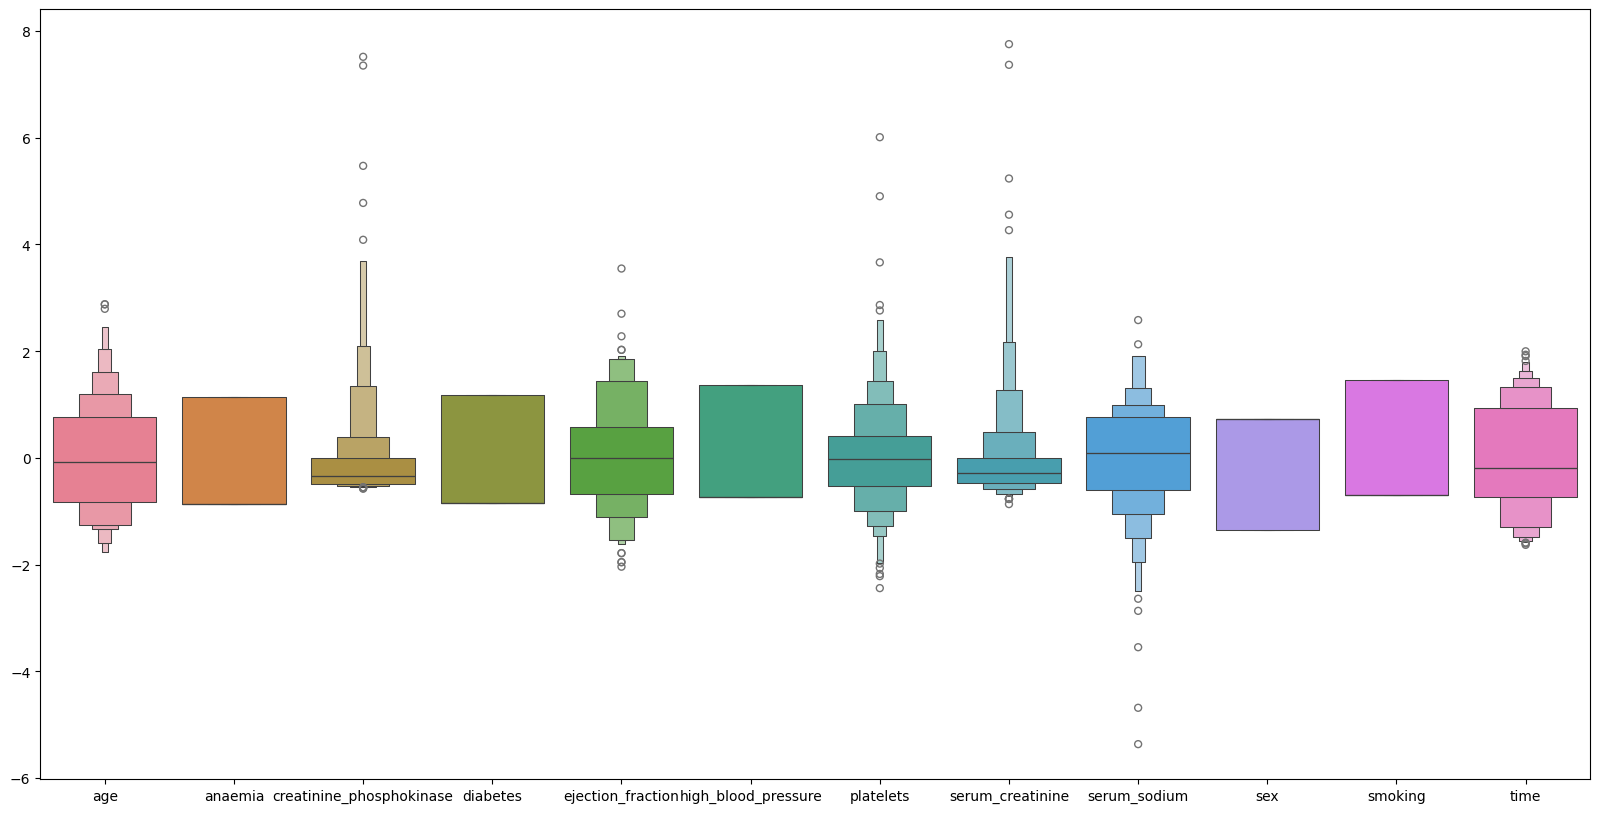

In [18]:
plt.figure(figsize=(20,10))
sns.boxenplot(data=X_scaled)
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3)

Model Building

SVM

In [20]:
model1 = svm.SVC()

In [21]:
model1.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [22]:
y_pred = model1.predict(X_test)

In [23]:
y_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0])

In [24]:
list(y_test)

[1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0]

In [25]:
np.array(y_test)

array([1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 0])

<Axes: >

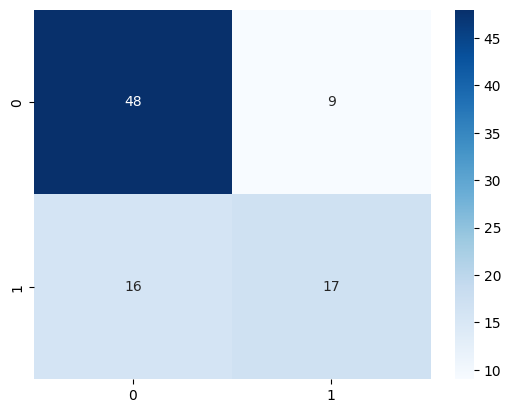

In [26]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, cmap="Blues")

In [27]:
accuracy_score(y_test,y_pred)

0.7222222222222222

In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.84      0.79        57
           1       0.65      0.52      0.58        33

    accuracy                           0.72        90
   macro avg       0.70      0.68      0.68        90
weighted avg       0.71      0.72      0.71        90



ANN

In [29]:
early_stoppin = callbacks.EarlyStopping(min_delta=0.001, patience=10,restore_best_weights=True)

model = Sequential()

model.add(Dense(units=32,activation='relu',input_dim=12))
model.add(Dense(units=16,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=8,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=1,activation='sigmoid')) 

In [30]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(X_train,y_train,batch_size=20,epochs=200,callbacks=[early_stoppin],validation_split=0.25)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5897 - loss: 0.7031 - val_accuracy: 0.6604 - val_loss: 0.6698
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5833 - loss: 0.7140 - val_accuracy: 0.6415 - val_loss: 0.6635
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5000 - loss: 0.7397 - val_accuracy: 0.6604 - val_loss: 0.6599
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6667 - loss: 0.6876 - val_accuracy: 0.6792 - val_loss: 0.6546
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6538 - loss: 0.6437 - val_accuracy: 0.6792 - val_loss: 0.6499
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6282 - loss: 0.6438 - val_accuracy: 0.6981 - val_loss: 0.6443
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6154 - loss: 0.6571 - val_accuracy: 0.6981 - val_loss: 0.6388
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6538 - loss: 0.6453 - val_accuracy: 0.7170 - val_loss:

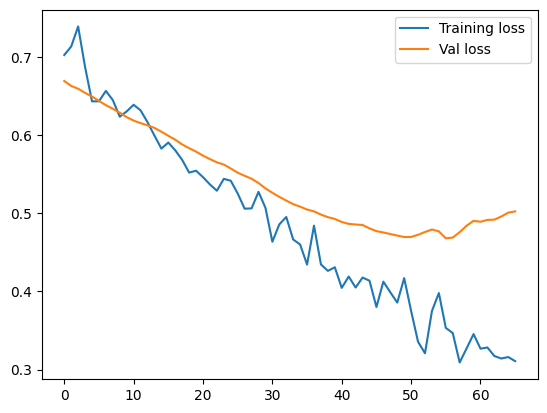

In [33]:
history_df = pd.DataFrame(history.history)

plt.plot(history_df['loss'], label="Training loss") 
plt.plot(history_df['val_loss'], label="Val loss")
plt.legend()
plt.show()

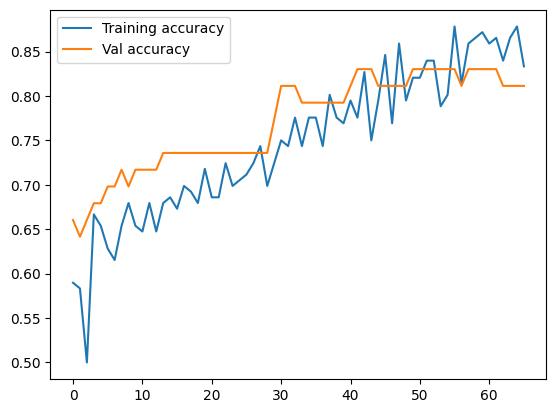

In [34]:
plt.plot(history_df['accuracy'], label="Training accuracy") 
plt.plot(history_df['val_accuracy'], label="Val accuracy")
plt.legend()
plt.show()

In [35]:
y_pred=model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [36]:
y_pred = (y_pred > 0.5)

<Axes: >

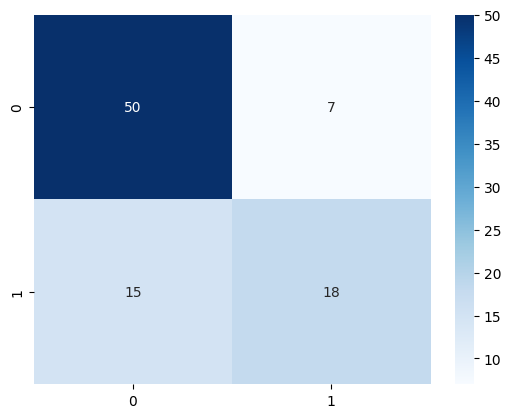

In [37]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, cmap="Blues")

In [38]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.88      0.82        57
           1       0.72      0.55      0.62        33

    accuracy                           0.76        90
   macro avg       0.74      0.71      0.72        90
weighted avg       0.75      0.76      0.75        90

